In [1]:

import os
import numpy as np
import pandas as pd

from sqlalchemy import create_engine, text

# ML / modelos
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    ExtraTreesClassifier,
)

import joblib
import matplotlib.pyplot as plt

# Parámetros globales
RANDOM_STATE = 42  # para reproducibilidad

# Conexión a Postgres usando mismas vars del proyecto 06
PG_HOST = os.getenv("PG_HOST", "postgres")
PG_PORT = os.getenv("PG_PORT", "5432")
PG_DB = os.getenv("PG_DB", "trading_db")
PG_USER = os.getenv("PG_USER", "trading_user")
PG_PASSWORD = os.getenv("PG_PASSWORD", "trading_pass")

engine = create_engine(
    f"postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DB}"
)

with engine.connect() as conn:
    conn.execute(text("SELECT 1;"))
print("Conexión a Postgres OK ✅")

Conexión a Postgres OK ✅


Sección Entrenamiento Activo **AAPL**

In [2]:
# Celda: helper para preparar datos por ticker (AAPL, NKE, MBG.DE)

def prepare_dataset_for_ticker(
    ticker,
    engine,
    train_end="2021-12-31",
    val_end="2023-12-31",
    test_end="2024-12-31",
):
    """
    Carga analytics.daily_features para un ticker dado,
    construye target + lags, define X, y y realiza el split temporal.
    Devuelve un dict con X_train, X_val, X_test, y_train, y_val, y_test, df_model.
    """

    print(f"\n=== Preparando dataset para {ticker} ===")

    query = f"""
        SELECT *
        FROM analytics.daily_features
        WHERE ticker = :ticker
        ORDER BY date
    """

    df = pd.read_sql(text(query), engine, params={"ticker": ticker})

    print("Shape bruto:", df.shape)
    df = df.sort_values("date").reset_index(drop=True)

    # Target: si la sesión cierra arriba de la apertura
    df["target_up"] = (df["close"] > df["open"]).astype(int)

    # Crear lags (igual que con AAPL)
    lag_cols = [
        "open",
        "close",
        "high",
        "low",
        "volume",
        "return_close_open",
        "return_prev_close",
        "volatility_n_days",
    ]

    for col in lag_cols:
        df[f"{col}_lag1"] = df[col].shift(1)

    # Flags de calendario a partir de day_of_week
    df["is_monday"] = df["day_of_week"] == 0
    df["is_friday"] = df["day_of_week"] == 4

    # Filtrar filas válidas (sin NaNs en lags/volatilidad)
    # NOTA: usamos volatility_n_days_lag1 implícito (ya que lagueamos volatility_n_days)
    lag_feature_cols = [
        "open_lag1",
        "close_lag1",
        "high_lag1",
        "low_lag1",
        "volume_lag1",
        "return_close_open_lag1",
        "return_prev_close_lag1",
        "volatility_n_days_lag1",
    ]

    mask_valid = df[lag_feature_cols].notnull().all(axis=1)
    df_model = df.loc[mask_valid].copy().reset_index(drop=True)

    print("Filas totales:", len(df))
    print("Filas válidas para modelar (con lags):", len(df_model))

    # Definir columnas de features (mismas que con AAPL)
    feature_cols = [
        "day_of_week",
        "is_monday",
        "is_friday",
        "open_lag1",
        "close_lag1",
        "high_lag1",
        "low_lag1",
        "volume_lag1",
        "return_close_open_lag1",
        "return_prev_close_lag1",
        "volatility_n_days_lag1",
    ]

    X = df_model[feature_cols].copy()
    y = df_model["target_up"].copy()

    # Convertir bool a int para is_monday / is_friday
    X["is_monday"] = X["is_monday"].astype(int)
    X["is_friday"] = X["is_friday"].astype(int)

    print("Shape X:", X.shape)
    print("Distribución y:")
    print(y.value_counts(normalize=True))

    # Split temporal
    df_model["date"] = pd.to_datetime(df_model["date"])
    dates = df_model["date"]

    train_end_dt = pd.to_datetime(train_end)
    val_end_dt = pd.to_datetime(val_end)
    test_end_dt = pd.to_datetime(test_end)

    mask_train = dates <= train_end_dt
    mask_val = (dates > train_end_dt) & (dates <= val_end_dt)
    mask_test = (dates > val_end_dt) & (dates <= test_end_dt)

    X_train, y_train = X[mask_train], y[mask_train]
    X_val, y_val     = X[mask_val], y[mask_val]
    X_test, y_test   = X[mask_test], y[mask_test]

    print("\nSplit temporal:")
    print("Train:", X_train.shape, "rango:", dates[mask_train].min(), "→", dates[mask_train].max())
    print("Val  :", X_val.shape,   "rango:", dates[mask_val].min(),   "→", dates[mask_val].max())
    print("Test :", X_test.shape,  "rango:", dates[mask_test].min(),  "→", dates[mask_test].max())

    print("\nDistribución y por split:")
    for split_name, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
        print(split_name, "->")
        print(yy.value_counts(normalize=True))

    return {
        "df_model": df_model,
        "X": X,
        "y": y,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "feature_cols": feature_cols,
    }

In [3]:
query = """
    SELECT *
    FROM analytics.daily_features
    WHERE ticker = 'AAPL'
    ORDER BY date
"""

df = pd.read_sql(query, engine)

print(df.shape)
df.head()

(1988, 17)


,date,ticker,year,month,day_of_week,open,close,high,low,volume,return_close_open,return_prev_close,volatility_n_days,is_monday,is_friday,run_id,ingested_at_utc
0,2018-01-02,AAPL,2018,1,1,42.540001,43.064999,43.075001,42.314999,102223600,0.012341,NaN,NaN,False,False,feat_run_001,2025-12-01 19:29:52.289275+00:00
1,2018-01-03,AAPL,2018,1,2,43.132500,43.057499,43.637501,42.990002,118071600,-0.001739,-0.000174,NaN,False,False,feat_run_001,2025-12-01 19:29:52.289275+00:00
2,2018-01-04,AAPL,2018,1,3,43.134998,43.257500,43.367500,43.020000,89738400,0.002840,0.004645,NaN,False,False,feat_run_001,2025-12-01 19:29:52.289275+00:00
3,2018-01-05,AAPL,2018,1,4,43.360001,43.750000,43.842499,43.262501,94640000,0.008994,0.011385,NaN,False,True,feat_run_001,2025-12-01 19:29:52.289275+00:00
4,2018-01-08,AAPL,2018,1,0,43.587502,43.587502,43.902500,43.482498,82271200,0.000000,-0.003714,NaN,True,False,feat_run_001,2025-12-01 19:29:52.289275+00:00


Distribución target_up_tmp (close > open):
target_up_tmp
1    0.537726
0    0.462274
Name: proportion, dtype: float64


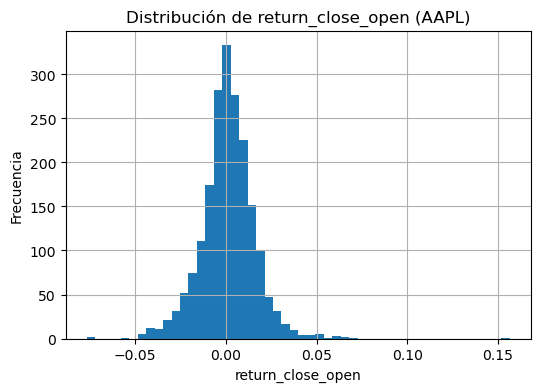

In [4]:
# Definir temporalmente el target para ver distribución (luego lo refinamos con lags)
df["target_up_tmp"] = (df["close"] > df["open"]).astype(int)

print("Distribución target_up_tmp (close > open):")
print(df["target_up_tmp"].value_counts(normalize=True))

# Histograma de return_close_open
plt.figure(figsize=(6,4))
df["return_close_open"].hist(bins=50)
plt.title("Distribución de return_close_open (AAPL)")
plt.xlabel("return_close_open")
plt.ylabel("Frecuencia")
plt.show()

In [5]:

df = df.sort_values("date").reset_index(drop=True)

# Target: si la sesión cierra arriba de la apertura
df["target_up"] = (df["close"] > df["open"]).astype(int)

# Columnas sobre las que crearemos lags (info de día t-1)
lag_cols = [
    "open",
    "close",
    "high",
    "low",
    "volume",
    "return_close_open",
    "return_prev_close",
    "volatility_n_days",
]

for col in lag_cols:
    df[f"{col}_lag1"] = df[col].shift(1)

# Features de calendario (del día t, las conocemos antes de abrir mercado)
# day_of_week ya existe en la tabla
# is_monday / is_friday también, pero reafirmamos a partir de day_of_week por seguridad
df["is_monday"] = df["day_of_week"] == 0
df["is_friday"] = df["day_of_week"] == 4

# Filtrar filas válidas: quitar primeras filas sin lags o sin volatilidad
mask_valid = df[["open_lag1", "volatility_n_days_lag1"]] \
    .notnull() \
    .all(axis=1)

df_model = df.loc[mask_valid].copy()
df_model.reset_index(drop=True, inplace=True)

print("Filas totales:", len(df))
print("Filas válidas para modelar (con lags):", len(df_model))

df_model[["date", "open", "close", "target_up"]].head()

Filas totales: 1988
Filas válidas para modelar (con lags): 1977


,date,open,close,target_up
0,2018-01-18,44.842499,44.814999,0
1,2018-01-19,44.652500,44.615002,0
2,2018-01-22,44.325001,44.250000,0
3,2018-01-23,44.325001,44.259998,0
4,2018-01-24,44.312500,43.555000,0


In [6]:
# Seleccionar columnas de features (todas de día t-1 + calendario de t)
feature_cols = [
    "day_of_week",
    "is_monday",
    "is_friday",
    "open_lag1",
    "close_lag1",
    "high_lag1",
    "low_lag1",
    "volume_lag1",
    "return_close_open_lag1",
    "return_prev_close_lag1",
    "volatility_n_days_lag1",
]

X = df_model[feature_cols].copy()
y = df_model["target_up"].copy()

# Convertir bool a int (0/1) para que todo sea numérico
X["is_monday"] = X["is_monday"].astype(int)
X["is_friday"] = X["is_friday"].astype(int)

print("Shape X:", X.shape)
print("Distribución y:")
print(y.value_counts(normalize=True))

Shape X: (1977, 11)
Distribución y:
target_up
1    0.537178
0    0.462822
Name: proportion, dtype: float64


In [7]:

df_model["date"] = pd.to_datetime(df_model["date"])
dates = df_model["date"]

train_end = pd.to_datetime("2021-12-31")
val_end = pd.to_datetime("2023-12-31")
test_end = pd.to_datetime("2024-12-31")

mask_train = dates <= train_end
mask_val = (dates > train_end) & (dates <= val_end)
mask_test = (dates > val_end) & (dates <= test_end)
mask_2025 = dates > test_end  # se usará para simulación luego

X_train, y_train = X[mask_train], y[mask_train]
X_val, y_val     = X[mask_val], y[mask_val]
X_test, y_test   = X[mask_test], y[mask_test]

print("Train:", X_train.shape, "rango:", dates[mask_train].min(), "→", dates[mask_train].max())
print("Val  :", X_val.shape,   "rango:", dates[mask_val].min(),   "→", dates[mask_val].max())
print("Test :", X_test.shape,  "rango:", dates[mask_test].min(),  "→", dates[mask_test].max())

print("\nDistribución y por split:")
for split_name, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(split_name, "->", yy.value_counts(normalize=True))

Train: (997, 11) rango: 2018-01-18 00:00:00 → 2021-12-31 00:00:00
Val  : (501, 11) rango: 2022-01-03 00:00:00 → 2023-12-29 00:00:00
Test : (252, 11) rango: 2024-01-02 00:00:00 → 2024-12-31 00:00:00

Distribución y por split:
Train -> target_up
1    0.531595
0    0.468405
Name: proportion, dtype: float64
Val -> target_up
1    0.55489
0    0.44511
Name: proportion, dtype: float64
Test -> target_up
1    0.543651
0    0.456349
Name: proportion, dtype: float64


In [8]:

def compute_metrics(model, X, y, split_name=""):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)

    # ROC-AUC (si el modelo tiene predict_proba o decision_function)
    try:
        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X)[:, 1]
        elif hasattr(model, "decision_function"):
            y_scores = model.decision_function(X)
        else:
            y_scores = None
        roc = roc_auc_score(y, y_scores) if y_scores is not None else np.nan
    except Exception:
        roc = np.nan

    return {
        "split": split_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc,
    }

# Baseline: DummyClassifier (clase mayoritaria)
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

metrics_baseline_train = compute_metrics(baseline, X_train, y_train, "train")
metrics_baseline_val   = compute_metrics(baseline, X_val, y_val, "val")

print("Baseline (DummyClassifier, clase mayoritaria)")
print("Train:", metrics_baseline_train)
print("Val  :", metrics_baseline_val)

Baseline (DummyClassifier, clase mayoritaria)
Train: {'split': 'train', 'accuracy': 0.5315947843530592, 'precision': 0.5315947843530592, 'recall': 1.0, 'f1': 0.6941715782580223, 'roc_auc': 0.5}
Val  : {'split': 'val', 'accuracy': 0.5548902195608783, 'precision': 0.5548902195608783, 'recall': 1.0, 'f1': 0.7137355584082157, 'roc_auc': 0.5}


In [9]:

tscv = TimeSeriesSplit(n_splits=3)

def train_with_gridsearch(name, base_clf, param_grid):
    """
    Crea un pipeline (scaler + clf), hace GridSearchCV sobre Train y devuelve:
    - best_model (pipeline)
    - metrics_train
    - metrics_val
    """
    pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("clf", base_clf),
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=tscv,
        scoring="f1",
        n_jobs=-1,
        verbose=1,
    )

    print(f"\n=== Entrenando modelo: {name} ===")
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    print(f"Mejores hiperparámetros para {name}: {grid.best_params_}")

    metrics_train = compute_metrics(best_model, X_train, y_train, "train")
    metrics_val   = compute_metrics(best_model, X_val, y_val, "val")

    return best_model, metrics_train, metrics_val

models_config = {
    "log_reg": {
        "clf": LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000,
        ),
        "param_grid": {
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__class_weight": [None, "balanced"],
        },
    },
    "linear_svc": {
        "clf": LinearSVC(
            random_state=RANDOM_STATE,
        ),
        "param_grid": {
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__class_weight": [None, "balanced"],
        },
    },
    "decision_tree": {
        "clf": DecisionTreeClassifier(
            random_state=RANDOM_STATE,
        ),
        "param_grid": {
            "clf__max_depth": [3, 5, 10, None],
            "clf__min_samples_leaf": [1, 5, 10],
        },
    },
    "random_forest": {
        "clf": RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "param_grid": {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [None, 5, 10],
            "clf__min_samples_leaf": [1, 5],
        },
    },
    "gradient_boosting": {
        "clf": GradientBoostingClassifier(
            random_state=RANDOM_STATE,
        ),
        "param_grid": {
            "clf__n_estimators": [100, 200],
            "clf__learning_rate": [0.05, 0.1],
            "clf__max_depth": [2, 3],
        },
    },
    "hist_gradient_boosting": {
        "clf": HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
        ),
        "param_grid": {
            "clf__learning_rate": [0.05, 0.1],
            "clf__max_depth": [None, 3],
            "clf__max_leaf_nodes": [31, 63],
        },
    },
    "extra_trees": {
        "clf": ExtraTreesClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "param_grid": {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [None, 5, 10],
            "clf__min_samples_leaf": [1, 5],
        },
    },
}

In [10]:

results = []
best_models = {}

for name, cfg in models_config.items():
    clf = cfg["clf"]
    param_grid = cfg["param_grid"]

    best_model, m_train, m_val = train_with_gridsearch(name, clf, param_grid)

    best_models[name] = best_model

    m_train["model"] = name
    m_val["model"]   = name

    results.append(m_train)
    results.append(m_val)

# Convertir resultados a DataFrame
metrics_df = pd.DataFrame(results)

# Añadir baseline a la tabla
baseline_train = metrics_baseline_train.copy()
baseline_train["model"] = "baseline_dummy"

baseline_val = metrics_baseline_val.copy()
baseline_val["model"] = "baseline_dummy"

metrics_df = pd.concat(
    [pd.DataFrame([baseline_train, baseline_val]), metrics_df],
    ignore_index=True
)

metrics_df


=== Entrenando modelo: log_reg ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para log_reg: {'clf__C': 0.1, 'clf__class_weight': None}

=== Entrenando modelo: linear_svc ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para linear_svc: {'clf__C': 0.01, 'clf__class_weight': None}

=== Entrenando modelo: decision_tree ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: Futu

Mejores hiperparámetros para decision_tree: {'clf__max_depth': None, 'clf__min_samples_leaf': 10}

=== Entrenando modelo: random_forest ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros para random_forest: {'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}

=== Entrenando modelo: gradient_boosting ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para gradient_boosting: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 100}

=== Entrenando modelo: hist_gradient_boosting ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para hist_gradient_boosting: {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_leaf_nodes': 31}

=== Entrenando modelo: extra_trees ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros para extra_trees: {'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__n_esti

,split,accuracy,precision,recall,f1,roc_auc,model
0,train,0.531595,0.531595,1.000000,0.694172,0.500000,baseline_dummy
1,val,0.554890,0.554890,1.000000,0.713736,0.500000,baseline_dummy
2,train,0.551655,0.559371,0.737736,0.636290,0.575835,log_reg
3,val,0.516966,0.557325,0.629496,0.591216,0.482627,log_reg
4,train,0.552658,0.560519,0.733962,0.635621,0.576090,linear_svc
5,val,0.510978,0.553398,0.615108,0.582624,0.482837,linear_svc
6,train,0.743230,0.764479,0.747170,0.755725,0.828132,decision_tree
7,val,0.540918,0.570175,0.701439,0.629032,0.520631,decision_tree
8,train,0.746239,0.706408,0.894340,0.789342,0.835776,random_forest
9,val,0.524950,0.553476,0.744604,0.634969,0.503565,random_forest


In [11]:
# Vista comparativa: F1 y ROC-AUC en validación por modelo

pivot_val = metrics_df[metrics_df["split"] == "val"] \
    .set_index("model")[["f1", "roc_auc", "accuracy", "precision", "recall"]] \
    .sort_values("f1", ascending=False)

pivot_val

,f1,roc_auc,accuracy,precision,recall
model,,,,,
baseline_dummy,0.713736,0.500000,0.554890,0.554890,1.000000
extra_trees,0.662757,0.504275,0.540918,0.559406,0.812950
random_forest,0.634969,0.503565,0.524950,0.553476,0.744604
decision_tree,0.629032,0.520631,0.540918,0.570175,0.701439
gradient_boosting,0.626543,0.516840,0.516966,0.548649,0.730216
log_reg,0.591216,0.482627,0.516966,0.557325,0.629496
hist_gradient_boosting,0.588629,0.504307,0.508982,0.550000,0.633094
linear_svc,0.582624,0.482837,0.510978,0.553398,0.615108


In [12]:

# Filtrar solo validación y excluir baseline en la selección
val_only = metrics_df[
    (metrics_df["split"] == "val") &
    (metrics_df["model"] != "baseline_dummy")
].copy()

best_model_name = val_only.sort_values("f1", ascending=False).iloc[0]["model"]
print("Modelo ganador según F1 en validación:", best_model_name)

best_model_val = best_models[best_model_name]

# Reentrenar el modelo ganador en Train+Val, como pide la rúbrica
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

best_model_final = best_model_val
best_model_final.fit(X_train_val, y_train_val)

metrics_train_val = compute_metrics(best_model_final, X_train_val, y_train_val, "train+val")
metrics_test      = compute_metrics(best_model_final, X_test, y_test, "test")

print("\nMétricas modelo ganador:")
print("Train+Val:", metrics_train_val)
print("Test     :", metrics_test)

# Matriz de confusión en Test
y_test_pred = best_model_final.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred)

print("\nMatriz de confusión (Test):")
print(cm)

print("\nReporte de clasificación (Test):")
print(classification_report(y_test, y_test_pred, digits=4))

Modelo ganador según F1 en validación: extra_trees

Métricas modelo ganador:
Train+Val: {'split': 'train+val', 'accuracy': 0.5700934579439252, 'precision': 0.5601173020527859, 'recall': 0.9455445544554455, 'f1': 0.7034990791896869, 'roc_auc': 0.6717445114076626}
Test     : {'split': 'test', 'accuracy': 0.5634920634920635, 'precision': 0.5652173913043478, 'recall': 0.8540145985401459, 'f1': 0.6802325581395348, 'roc_auc': 0.4875277689622342}

Matriz de confusión (Test):
[[ 25  90]
 [ 20 117]]

Reporte de clasificación (Test):
              precision    recall  f1-score   support

           0     0.5556    0.2174    0.3125       115
           1     0.5652    0.8540    0.6802       137

    accuracy                         0.5635       252
   macro avg     0.5604    0.5357    0.4964       252
weighted avg     0.5608    0.5635    0.5124       252



In [13]:

MODEL_PATH = os.getenv("MODEL_PATH", "work/models/best_model.pkl")

os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

joblib.dump(best_model_final, MODEL_PATH)

print(f"Modelo guardado en: {MODEL_PATH}")

PermissionError: [Errno 13] Permission denied: '/app'

In [14]:
# 1. Duplicados por fecha
df_model.duplicated(subset=["date"]).sum()

# 2. Nulos en features + target
(df_model[feature_cols + ["target_up"]].isna().sum())

# 3. Rangos básicos
df_model[["open_lag1", "close_lag1", "return_close_open_lag1"]].describe()

,open_lag1,close_lag1,return_close_open_lag1
count,1977.000000,1977.000000,1977.000000
mean,136.353589,136.490174,0.001082
std,64.683951,64.759642,0.015121
min,35.994999,35.547501,-0.076486
25%,66.735001,66.775002,-0.006577
50%,145.029999,145.520004,0.000938
75%,182.800003,182.910004,0.009374
max,276.989990,276.970001,0.156441


In [15]:
df_model.duplicated(subset=["date"]).sum()   # → 0 (lo esperable)
(df_model[feature_cols + ["target_up"]].isna().sum())  # → todo 0

day_of_week               0
is_monday                 0
is_friday                 0
open_lag1                 0
close_lag1                0
high_lag1                 0
low_lag1                  0
volume_lag1               0
return_close_open_lag1    0
return_prev_close_lag1    0
volatility_n_days_lag1    0
target_up                 0
dtype: int64

In [16]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 20.0 MB/s eta 0:00:00a 0:00:01


In [17]:
from xgboost import XGBClassifier

models_config["xgboost"] = {
    "clf": XGBClassifier(
        random_state=RANDOM_STATE,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        subsample=0.8,
        colsample_bytree=0.8,
    ),
    "param_grid": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [3, 4],
        "clf__learning_rate": [0.05, 0.1],
    },
}

In [18]:

results = []
best_models = {}

for name, cfg in models_config.items():
    clf = cfg["clf"]
    param_grid = cfg["param_grid"]

    best_model, m_train, m_val = train_with_gridsearch(name, clf, param_grid)

    best_models[name] = best_model

    m_train["model"] = name
    m_val["model"]   = name

    results.append(m_train)
    results.append(m_val)

# Convertir resultados a DataFrame
metrics_df = pd.DataFrame(results)

# Añadir baseline a la tabla
baseline_train = metrics_baseline_train.copy()
baseline_train["model"] = "baseline_dummy"

baseline_val = metrics_baseline_val.copy()
baseline_val["model"] = "baseline_dummy"

metrics_df = pd.concat(
    [pd.DataFrame([baseline_train, baseline_val]), metrics_df],
    ignore_index=True
)

metrics_df


=== Entrenando modelo: log_reg ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para log_reg: {'clf__C': 0.1, 'clf__class_weight': None}

=== Entrenando modelo: linear_svc ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para linear_svc: {'clf__C': 0.01, 'clf__class_weight': None}

=== Entrenando modelo: decision_tree ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: Futu

Mejores hiperparámetros para decision_tree: {'clf__max_depth': None, 'clf__min_samples_leaf': 10}

=== Entrenando modelo: random_forest ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros para random_forest: {'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}

=== Entrenando modelo: gradient_boosting ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para gradient_boosting: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 100}

=== Entrenando modelo: hist_gradient_boosting ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para hist_gradient_boosting: {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_leaf_nodes': 31}

=== Entrenando modelo: extra_trees ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros para extra_trees: {'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__n_esti

,split,accuracy,precision,recall,f1,roc_auc,model
0,train,0.531595,0.531595,1.000000,0.694172,0.500000,baseline_dummy
1,val,0.554890,0.554890,1.000000,0.713736,0.500000,baseline_dummy
2,train,0.551655,0.559371,0.737736,0.636290,0.575835,log_reg
3,val,0.516966,0.557325,0.629496,0.591216,0.482627,log_reg
4,train,0.552658,0.560519,0.733962,0.635621,0.576090,linear_svc
5,val,0.510978,0.553398,0.615108,0.582624,0.482837,linear_svc
6,train,0.743230,0.764479,0.747170,0.755725,0.828132,decision_tree
7,val,0.540918,0.570175,0.701439,0.629032,0.520631,decision_tree
8,train,0.746239,0.706408,0.894340,0.789342,0.835776,random_forest
9,val,0.524950,0.553476,0.744604,0.634969,0.503565,random_forest


In [19]:

# Filtrar solo validación y excluir baseline en la selección
val_only = metrics_df[
    (metrics_df["split"] == "val") &
    (metrics_df["model"] != "baseline_dummy")
].copy()

best_model_name = val_only.sort_values("f1", ascending=False).iloc[0]["model"]
print("Modelo ganador según F1 en validación:", best_model_name)

best_model_val = best_models[best_model_name]

# Reentrenar el modelo ganador en Train+Val, como pide la rúbrica
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

best_model_final = best_model_val
best_model_final.fit(X_train_val, y_train_val)

metrics_train_val = compute_metrics(best_model_final, X_train_val, y_train_val, "train+val")
metrics_test      = compute_metrics(best_model_final, X_test, y_test, "test")

print("\nMétricas modelo ganador:")
print("Train+Val:", metrics_train_val)
print("Test     :", metrics_test)

# Matriz de confusión en Test
y_test_pred = best_model_final.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred)

print("\nMatriz de confusión (Test):")
print(cm)

print("\nReporte de clasificación (Test):")
print(classification_report(y_test, y_test_pred, digits=4))

Modelo ganador según F1 en validación: extra_trees

Métricas modelo ganador:
Train+Val: {'split': 'train+val', 'accuracy': 0.5700934579439252, 'precision': 0.5601173020527859, 'recall': 0.9455445544554455, 'f1': 0.7034990791896869, 'roc_auc': 0.6717445114076626}
Test     : {'split': 'test', 'accuracy': 0.5634920634920635, 'precision': 0.5652173913043478, 'recall': 0.8540145985401459, 'f1': 0.6802325581395348, 'roc_auc': 0.4875277689622342}

Matriz de confusión (Test):
[[ 25  90]
 [ 20 117]]

Reporte de clasificación (Test):
              precision    recall  f1-score   support

           0     0.5556    0.2174    0.3125       115
           1     0.5652    0.8540    0.6802       137

    accuracy                         0.5635       252
   macro avg     0.5604    0.5357    0.4964       252
weighted avg     0.5608    0.5635    0.5124       252



In [20]:
# Vista comparativa: F1 y ROC-AUC en validación por modelo

pivot_val = metrics_df[metrics_df["split"] == "val"] \
    .set_index("model")[["f1", "roc_auc", "accuracy", "precision", "recall"]] \
    .sort_values("f1", ascending=False)

pivot_val

,f1,roc_auc,accuracy,precision,recall
model,,,,,
baseline_dummy,0.713736,0.500000,0.554890,0.554890,1.000000
extra_trees,0.662757,0.504275,0.540918,0.559406,0.812950
random_forest,0.634969,0.503565,0.524950,0.553476,0.744604
decision_tree,0.629032,0.520631,0.540918,0.570175,0.701439
gradient_boosting,0.626543,0.516840,0.516966,0.548649,0.730216
log_reg,0.591216,0.482627,0.516966,0.557325,0.629496
xgboost,0.590832,0.506017,0.518962,0.559486,0.625899
hist_gradient_boosting,0.588629,0.504307,0.508982,0.550000,0.633094
linear_svc,0.582624,0.482837,0.510978,0.553398,0.615108


Sección Entrenamiento Activo **NKE**

In [21]:
# Celda: helpers de métricas y configuración de modelos (AAPL, NKE, MBG.DE)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    ExtraTreesClassifier,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

from xgboost import XGBClassifier  # asegúrate de tenerlo instalado: pip install xgboost

RANDOM_STATE = 42
tscv = TimeSeriesSplit(n_splits=3)


def compute_metrics(model, X, y, split_name=""):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)

    try:
        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X)[:, 1]
        elif hasattr(model, "decision_function"):
            y_scores = model.decision_function(X)
        else:
            y_scores = None
        roc = roc_auc_score(y, y_scores) if y_scores is not None else np.nan
    except Exception:
        roc = np.nan

    return {
        "split": split_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc,
    }


def train_with_gridsearch(name, base_clf, param_grid, X_train, y_train):
    pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("clf", base_clf),
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=tscv,
        scoring="f1",
        n_jobs=-1,
        verbose=1,
    )

    print(f"\n=== Entrenando modelo: {name} ===")
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    print(f"Mejores hiperparámetros para {name}: {grid.best_params_}")

    return best_model


models_config = {
    "log_reg": {
        "clf": LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000,
        ),
        "param_grid": {
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__class_weight": [None, "balanced"],
        },
    },
    "linear_svc": {
        "clf": LinearSVC(
            random_state=RANDOM_STATE,
        ),
        "param_grid": {
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__class_weight": [None, "balanced"],
        },
    },
    "decision_tree": {
        "clf": DecisionTreeClassifier(
            random_state=RANDOM_STATE,
        ),
        "param_grid": {
            "clf__max_depth": [3, 5, 10, None],
            "clf__min_samples_leaf": [1, 5, 10],
        },
    },
    "random_forest": {
        "clf": RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "param_grid": {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [None, 5, 10],
            "clf__min_samples_leaf": [1, 5],
        },
    },
    "gradient_boosting": {
        "clf": GradientBoostingClassifier(
            random_state=RANDOM_STATE,
        ),
        "param_grid": {
            "clf__n_estimators": [100, 200],
            "clf__learning_rate": [0.05, 0.1],
            "clf__max_depth": [2, 3],
        },
    },
    "hist_gradient_boosting": {
        "clf": HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
        ),
        "param_grid": {
            "clf__learning_rate": [0.05, 0.1],
            "clf__max_depth": [None, 3],
            "clf__max_leaf_nodes": [31, 63],
        },
    },
    "extra_trees": {
        "clf": ExtraTreesClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "param_grid": {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [None, 5, 10],
            "clf__min_samples_leaf": [1, 5],
        },
    },
    "xgboost": {
        "clf": XGBClassifier(
            random_state=RANDOM_STATE,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            n_jobs=-1,
        ),
        "param_grid": {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [3, 4],
            "clf__learning_rate": [0.05, 0.1],
            "clf__subsample": [0.8, 1.0],
            "clf__colsample_bytree": [0.8, 1.0],
        },
    },
}

In [22]:
# Celda: correr experimento completo para un ticker

def run_experiment_for_ticker(ticker, engine):
    # 1) Preparar dataset
    data = prepare_dataset_for_ticker(ticker, engine)
    X_train = data["X_train"]
    X_val   = data["X_val"]
    X_test  = data["X_test"]
    y_train = data["y_train"]
    y_val   = data["y_val"]
    y_test  = data["y_test"]

    # 2) Baseline
    baseline = DummyClassifier(strategy="most_frequent")
    baseline.fit(X_train, y_train)

    metrics_baseline_train = compute_metrics(baseline, X_train, y_train, "train")
    metrics_baseline_val   = compute_metrics(baseline, X_val,   y_val,   "val")

    metrics_baseline_train["model"] = "baseline_dummy"
    metrics_baseline_val["model"]   = "baseline_dummy"

    results = [metrics_baseline_train, metrics_baseline_val]
    best_models = {}

    # 3) Modelos con GridSearch
    for name, cfg in models_config.items():
        clf = cfg["clf"]
        param_grid = cfg["param_grid"]

        best_model = train_with_gridsearch(
            name=name,
            base_clf=clf,
            param_grid=param_grid,
            X_train=X_train,
            y_train=y_train,
        )

        best_models[name] = best_model

        m_train = compute_metrics(best_model, X_train, y_train, "train")
        m_val   = compute_metrics(best_model, X_val,   y_val,   "val")

        m_train["model"] = name
        m_val["model"]   = name

        results.append(m_train)
        results.append(m_val)

    metrics_df = pd.DataFrame(results)

    # Vista pivot de validación
    pivot_val = metrics_df[metrics_df["split"] == "val"] \
        .set_index("model")[["f1", "roc_auc", "accuracy", "precision", "recall"]] \
        .sort_values("f1", ascending=False)

    print(f"\n=== Resultados en VALIDACIÓN para {ticker} ===")
    display(pivot_val)

    # 4) Seleccionar modelo ganador y evaluar en Test (como hiciste con AAPL)
    val_only = metrics_df[
        (metrics_df["split"] == "val") &
        (metrics_df["model"] != "baseline_dummy")
    ].copy()

    best_model_name = val_only.sort_values("f1", ascending=False).iloc[0]["model"]
    print(f"\nModelo ganador para {ticker} según F1 en validación: {best_model_name}")

    best_model_val = best_models[best_model_name]

    # Reentrenar en Train+Val
    X_train_val = pd.concat([X_train, X_val], axis=0)
    y_train_val = pd.concat([y_train, y_val], axis=0)

    best_model_final = best_model_val
    best_model_final.fit(X_train_val, y_train_val)

    metrics_train_val = compute_metrics(best_model_final, X_train_val, y_train_val, "train+val")
    metrics_test      = compute_metrics(best_model_final, X_test,      y_test,      "test")

    print("\nMétricas modelo ganador (Train+Val / Test):")
    print("Train+Val:", metrics_train_val)
    print("Test     :", metrics_test)

    return {
        "metrics_df": metrics_df,
        "pivot_val": pivot_val,
        "best_models": best_models,
        "best_model_name": best_model_name,
        "best_model_final": best_model_final,
    }

In [23]:
# === NKE ===

results_nke = run_experiment_for_ticker("NKE", engine)

metrics_nke = results_nke["metrics_df"]
pivot_nke_val = results_nke["pivot_val"]

pivot_nke_val  # esto te da una tabla muy similar a la de AAPL pero para NKE


=== Preparando dataset para NKE ===
Shape bruto: (1988, 17)
Filas totales: 1988
Filas válidas para modelar (con lags): 1977
Shape X: (1977, 11)
Distribución y:
target_up
1    0.506323
0    0.493677
Name: proportion, dtype: float64

Split temporal:
Train: (997, 11) rango: 2018-01-18 00:00:00 → 2021-12-31 00:00:00
Val  : (501, 11) rango: 2022-01-03 00:00:00 → 2023-12-29 00:00:00
Test : (252, 11) rango: 2024-01-02 00:00:00 → 2024-12-31 00:00:00

Distribución y por split:
Train ->
target_up
1    0.509529
0    0.490471
Name: proportion, dtype: float64
Val ->
target_up
1    0.522954
0    0.477046
Name: proportion, dtype: float64
Test ->
target_up
1    0.503968
0    0.496032
Name: proportion, dtype: float64

=== Entrenando modelo: log_reg ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para log_reg: {'clf__C': 10, 'clf__class_weight': None}

=== Entrenando modelo: linear_svc ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: Futu

Mejores hiperparámetros para linear_svc: {'clf__C': 10, 'clf__class_weight': None}

=== Entrenando modelo: decision_tree ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros para decision_tree: {'clf__max_depth': 3, 'clf__min_samples_leaf': 5}

=== Entrenando modelo: random_forest ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros para random_forest: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100}

=== Entrenando modelo: gradient_boosting ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para gradient_boosting: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200}

=== Entrenando modelo: hist_gradient_boosting ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para hist_gradient_boosting: {'clf__learning_rate': 0.1, 'clf__max_depth': None, 'clf__max_leaf_nodes': 63}

=== Entrenando model

,f1,roc_auc,accuracy,precision,recall
model,,,,,
baseline_dummy,0.686763,0.500000,0.522954,0.522954,1.000000
decision_tree,0.671214,0.498914,0.518962,0.522293,0.938931
random_forest,0.565295,0.499625,0.514970,0.531987,0.603053
extra_trees,0.560420,0.492159,0.499002,0.517799,0.610687
xgboost,0.555133,0.508336,0.532934,0.553030,0.557252
hist_gradient_boosting,0.547842,0.540372,0.518962,0.538745,0.557252
gradient_boosting,0.545788,0.499633,0.504990,0.524648,0.568702
log_reg,0.525735,0.481060,0.485030,0.507092,0.545802
linear_svc,0.500000,0.477978,0.473054,0.496241,0.503817



Modelo ganador para NKE según F1 en validación: decision_tree

Métricas modelo ganador (Train+Val / Test):
Train+Val: {'split': 'train+val', 'accuracy': 0.554739652870494, 'precision': 0.5472910927456383, 'recall': 0.7740259740259741, 'f1': 0.6412049488972567, 'roc_auc': 0.5564435564435565}
Test     : {'split': 'test', 'accuracy': 0.503968253968254, 'precision': 0.5059523809523809, 'recall': 0.6692913385826772, 'f1': 0.5762711864406779, 'roc_auc': 0.5026456692913386}


,f1,roc_auc,accuracy,precision,recall
model,,,,,
baseline_dummy,0.686763,0.500000,0.522954,0.522954,1.000000
decision_tree,0.671214,0.498914,0.518962,0.522293,0.938931
random_forest,0.565295,0.499625,0.514970,0.531987,0.603053
extra_trees,0.560420,0.492159,0.499002,0.517799,0.610687
xgboost,0.555133,0.508336,0.532934,0.553030,0.557252
hist_gradient_boosting,0.547842,0.540372,0.518962,0.538745,0.557252
gradient_boosting,0.545788,0.499633,0.504990,0.524648,0.568702
log_reg,0.525735,0.481060,0.485030,0.507092,0.545802
linear_svc,0.500000,0.477978,0.473054,0.496241,0.503817


Sección Entrenamiento Activo **MBG.D**

In [24]:
# === MBG.DE ===

results_mbg = run_experiment_for_ticker("MBG.DE", engine)

metrics_mbg = results_mbg["metrics_df"]
pivot_mbg_val = results_mbg["pivot_val"]

pivot_mbg_val


=== Preparando dataset para MBG.DE ===
Shape bruto: (2011, 17)
Filas totales: 2011
Filas válidas para modelar (con lags): 2000
Shape X: (2000, 11)
Distribución y:
target_up
0    0.516
1    0.484
Name: proportion, dtype: float64

Split temporal:
Train: (1001, 11) rango: 2018-01-17 00:00:00 → 2021-12-30 00:00:00
Val  : (512, 11) rango: 2022-01-03 00:00:00 → 2023-12-29 00:00:00
Test : (254, 11) rango: 2024-01-02 00:00:00 → 2024-12-30 00:00:00

Distribución y por split:
Train ->
target_up
0    0.505495
1    0.494505
Name: proportion, dtype: float64
Val ->
target_up
0    0.537109
1    0.462891
Name: proportion, dtype: float64
Test ->
target_up
1    0.507874
0    0.492126
Name: proportion, dtype: float64

=== Entrenando modelo: log_reg ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para log_reg: {'clf__C': 0.01, 'clf__class_weight': 'balanced'}

=== Entrenando modelo: linear_svc ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: Futu

Mejores hiperparámetros para linear_svc: {'clf__C': 10, 'clf__class_weight': 'balanced'}

=== Entrenando modelo: decision_tree ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros para decision_tree: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1}

=== Entrenando modelo: random_forest ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros para random_forest: {'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100}

=== Entrenando modelo: gradient_boosting ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para gradient_boosting: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100}

=== Entrenando modelo: hist_gradient_boosting ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para hist_gradient_boosting: {'clf__learning_rate': 0.1, 'clf__max_depth': None, 'clf__max_leaf_nodes': 63}

=== Entrenando mo

,f1,roc_auc,accuracy,precision,recall
model,,,,,
decision_tree,0.626573,0.529076,0.478516,0.468619,0.945148
log_reg,0.616314,0.510257,0.503906,0.480000,0.860759
linear_svc,0.607717,0.520353,0.523438,0.490909,0.797468
gradient_boosting,0.489362,0.525255,0.531250,0.493562,0.485232
hist_gradient_boosting,0.465217,0.530004,0.519531,0.479821,0.451477
random_forest,0.446953,0.512574,0.521484,0.480583,0.417722
extra_trees,0.441113,0.482892,0.490234,0.447826,0.434599
xgboost,0.440909,0.499639,0.519531,0.477833,0.409283
baseline_dummy,0.000000,0.500000,0.537109,0.000000,0.000000



Modelo ganador para MBG.DE según F1 en validación: decision_tree

Métricas modelo ganador (Train+Val / Test):
Train+Val: {'split': 'train+val', 'accuracy': 0.5373430270984798, 'precision': 0.82, 'recall': 0.056010928961748634, 'f1': 0.10485933503836316, 'roc_auc': 0.5699843622090217}
Test     : {'split': 'test', 'accuracy': 0.4921259842519685, 'precision': 0.5, 'recall': 0.015503875968992248, 'f1': 0.03007518796992481, 'roc_auc': 0.5082170542635659}


,f1,roc_auc,accuracy,precision,recall
model,,,,,
decision_tree,0.626573,0.529076,0.478516,0.468619,0.945148
log_reg,0.616314,0.510257,0.503906,0.480000,0.860759
linear_svc,0.607717,0.520353,0.523438,0.490909,0.797468
gradient_boosting,0.489362,0.525255,0.531250,0.493562,0.485232
hist_gradient_boosting,0.465217,0.530004,0.519531,0.479821,0.451477
random_forest,0.446953,0.512574,0.521484,0.480583,0.417722
extra_trees,0.441113,0.482892,0.490234,0.447826,0.434599
xgboost,0.440909,0.499639,0.519531,0.477833,0.409283
baseline_dummy,0.000000,0.500000,0.537109,0.000000,0.000000


**Guardar mejores modelos**

In [25]:
# Celda: helper para guardar los mejores modelos por activo

import joblib
from pathlib import Path

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

def save_best_model_for_ticker(ticker, results_dict, models_dir: Path = MODELS_DIR):
    """
    Guarda el mejor modelo (pipeline completo: scaler + modelo) para un ticker dado.
    
    - ticker: string, ej. "AAPL", "NKE", "MBG.DE"
    - results_dict: dict devuelto por run_experiment_for_ticker(...)
        Debe contener:
          - "best_model_name"
          - "best_model_final" (reentrenado en Train+Val)
    """
    best_model_name = results_dict["best_model_name"]
    best_model = results_dict["best_model_final"]

    # Sanitizar ticker para el nombre del archivo (quitar puntos)
    ticker_safe = ticker.replace(".", "_")
    model_path = models_dir / f"best_model_{ticker_safe}.pkl"

    joblib.dump(best_model, model_path)

    print(f"Modelo guardado para {ticker} ({best_model_name}) en: {model_path}")
    return model_path

In [26]:
# Celda: correr experimentos (si no lo hiciste antes)

# AAPL
results_aapl = run_experiment_for_ticker("AAPL", engine)

# NKE
results_nke = run_experiment_for_ticker("NKE", engine)

# MBG.DE
results_mbg = run_experiment_for_ticker("MBG.DE", engine)


=== Preparando dataset para AAPL ===
Shape bruto: (1988, 17)
Filas totales: 1988
Filas válidas para modelar (con lags): 1977
Shape X: (1977, 11)
Distribución y:
target_up
1    0.537178
0    0.462822
Name: proportion, dtype: float64

Split temporal:
Train: (997, 11) rango: 2018-01-18 00:00:00 → 2021-12-31 00:00:00
Val  : (501, 11) rango: 2022-01-03 00:00:00 → 2023-12-29 00:00:00
Test : (252, 11) rango: 2024-01-02 00:00:00 → 2024-12-31 00:00:00

Distribución y por split:
Train ->
target_up
1    0.531595
0    0.468405
Name: proportion, dtype: float64
Val ->
target_up
1    0.55489
0    0.44511
Name: proportion, dtype: float64
Test ->
target_up
1    0.543651
0    0.456349
Name: proportion, dtype: float64

=== Entrenando modelo: log_reg ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para log_reg: {'clf__C': 0.1, 'clf__class_weight': None}

=== Entrenando modelo: linear_svc ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperp

/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: Futu

Mejores hiperparámetros para decision_tree: {'clf__max_depth': None, 'clf__min_samples_leaf': 10}

=== Entrenando modelo: random_forest ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros para random_forest: {'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}

=== Entrenando modelo: gradient_boosting ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para gradient_boosting: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 100}

=== Entrenando modelo: hist_gradient_boosting ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para hist_gradient_boosting: {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_leaf_nodes': 31}

=== Entrenando modelo: extra_trees ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros para extra_trees: {'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__n_esti

,f1,roc_auc,accuracy,precision,recall
model,,,,,
baseline_dummy,0.713736,0.500000,0.554890,0.554890,1.000000
extra_trees,0.662757,0.504275,0.540918,0.559406,0.812950
random_forest,0.634969,0.503565,0.524950,0.553476,0.744604
decision_tree,0.629032,0.520631,0.540918,0.570175,0.701439
gradient_boosting,0.626543,0.516840,0.516966,0.548649,0.730216
log_reg,0.591216,0.482627,0.516966,0.557325,0.629496
xgboost,0.590832,0.506017,0.518962,0.559486,0.625899
hist_gradient_boosting,0.588629,0.504307,0.508982,0.550000,0.633094
linear_svc,0.582624,0.482837,0.510978,0.553398,0.615108



Modelo ganador para AAPL según F1 en validación: extra_trees

Métricas modelo ganador (Train+Val / Test):
Train+Val: {'split': 'train+val', 'accuracy': 0.5700934579439252, 'precision': 0.5601173020527859, 'recall': 0.9455445544554455, 'f1': 0.7034990791896869, 'roc_auc': 0.6717445114076626}
Test     : {'split': 'test', 'accuracy': 0.5634920634920635, 'precision': 0.5652173913043478, 'recall': 0.8540145985401459, 'f1': 0.6802325581395348, 'roc_auc': 0.4875277689622342}

=== Preparando dataset para NKE ===
Shape bruto: (1988, 17)
Filas totales: 1988
Filas válidas para modelar (con lags): 1977
Shape X: (1977, 11)
Distribución y:
target_up
1    0.506323
0    0.493677
Name: proportion, dtype: float64

Split temporal:
Train: (997, 11) rango: 2018-01-18 00:00:00 → 2021-12-31 00:00:00
Val  : (501, 11) rango: 2022-01-03 00:00:00 → 2023-12-29 00:00:00
Test : (252, 11) rango: 2024-01-02 00:00:00 → 2024-12-31 00:00:00

Distribución y por split:
Train ->
target_up
1    0.509529
0    0.490471
Name:

...


Modelo ganador para NKE según F1 en validación: decision_tree

Métricas modelo ganador (Train+Val / Test):
Train+Val: {'split': 'train+val', 'accuracy': 0.554739652870494, 'precision': 0.5472910927456383, 'recall': 0.7740259740259741, 'f1': 0.6412049488972567, 'roc_auc': 0.5564435564435565}
Test     : {'split': 'test', 'accuracy': 0.503968253968254, 'precision': 0.5059523809523809, 'recall': 0.6692913385826772, 'f1': 0.5762711864406779, 'roc_auc': 0.5026456692913386}

=== Preparando dataset para MBG.DE ===
Shape bruto: (2011, 17)
Filas totales: 2011
Filas válidas para modelar (con lags): 2000
Shape X: (2000, 11)
Distribución y:
target_up
0    0.516
1    0.484
Name: proportion, dtype: float64

Split temporal:
Train: (1001, 11) rango: 2018-01-17 00:00:00 → 2021-12-30 00:00:00
Val  : (512, 11) rango: 2022-01-03 00:00:00 → 2023-12-29 00:00:00
Test : (254, 11) rango: 2024-01-02 00:00:00 → 2024-12-30 00:00:00

Distribución y por split:
Train ->
target_up
0    0.505495
1    0.494505
Name: pr

/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: Futu

Mejores hiperparámetros para linear_svc: {'clf__C': 10, 'clf__class_weight': 'balanced'}

=== Entrenando modelo: decision_tree ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros para decision_tree: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1}

=== Entrenando modelo: random_forest ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros para random_forest: {'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100}

=== Entrenando modelo: gradient_boosting ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para gradient_boosting: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100}

=== Entrenando modelo: hist_gradient_boosting ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros para hist_gradient_boosting: {'clf__learning_rate': 0.1, 'clf__max_depth': None, 'clf__max_leaf_nodes': 63}

=== Entrenando mo

,f1,roc_auc,accuracy,precision,recall
model,,,,,
decision_tree,0.626573,0.529076,0.478516,0.468619,0.945148
log_reg,0.616314,0.510257,0.503906,0.480000,0.860759
linear_svc,0.607717,0.520353,0.523438,0.490909,0.797468
gradient_boosting,0.489362,0.525255,0.531250,0.493562,0.485232
hist_gradient_boosting,0.465217,0.530004,0.519531,0.479821,0.451477
random_forest,0.446953,0.512574,0.521484,0.480583,0.417722
extra_trees,0.441113,0.482892,0.490234,0.447826,0.434599
xgboost,0.440909,0.499639,0.519531,0.477833,0.409283
baseline_dummy,0.000000,0.500000,0.537109,0.000000,0.000000



Modelo ganador para MBG.DE según F1 en validación: decision_tree

Métricas modelo ganador (Train+Val / Test):
Train+Val: {'split': 'train+val', 'accuracy': 0.5373430270984798, 'precision': 0.82, 'recall': 0.056010928961748634, 'f1': 0.10485933503836316, 'roc_auc': 0.5699843622090217}
Test     : {'split': 'test', 'accuracy': 0.4921259842519685, 'precision': 0.5, 'recall': 0.015503875968992248, 'f1': 0.03007518796992481, 'roc_auc': 0.5082170542635659}


In [27]:
# Celda: guardar mejores modelos de cada activo

path_aapl = save_best_model_for_ticker("AAPL", results_aapl)
path_nke  = save_best_model_for_ticker("NKE", results_nke)
path_mbg  = save_best_model_for_ticker("MBG.DE", results_mbg)

print("\nRutas finales de los modelos serializados:")
print("AAPL  ->", path_aapl)
print("NKE   ->", path_nke)
print("MBGDE ->", path_mbg)

Modelo guardado para AAPL (extra_trees) en: models/best_model_AAPL.pkl
Modelo guardado para NKE (decision_tree) en: models/best_model_NKE.pkl
Modelo guardado para MBG.DE (decision_tree) en: models/best_model_MBG_DE.pkl

Rutas finales de los modelos serializados:
AAPL  -> models/best_model_AAPL.pkl
NKE   -> models/best_model_NKE.pkl
MBGDE -> models/best_model_MBG_DE.pkl


## Resumen del notebook de ML (`02_ml_trading_classifier.ipynb`)

En este notebook se entrena y evalúa un clasificador para predecir la dirección intradía de varios activos bursátiles (AAPL, NKE y MBG.DE), utilizando como fuente única la tabla `analytics.daily_features` construida en el Proyecto 06.

**Definición del problema**

- **Target (`target_up`)**: variable binaria que vale 1 si el precio de cierre del día (`close`) es mayor que el precio de apertura (`open`), y 0 en caso contrario.
- **Objetivo de negocio**: anticipar si conviene entrar largo intradía (comprar en la apertura y vender en el cierre) o permanecer en efectivo.

**Variables de entrada**

- Features formadas exclusivamente con **información del día t-1**:
  - `open_lag1`, `close_lag1`, `high_lag1`, `low_lag1`, `volume_lag1`
  - `return_close_open_lag1`, `return_prev_close_lag1`, `volatility_n_days_lag1`
- Variables de calendario del día actual:
  - `day_of_week`, `is_monday`, `is_friday`
- Se eliminan todas las filas que no tienen lags completos, evitando leakage.

**Split temporal de datos**

- Train: desde el inicio de la serie hasta **2021-12-31**.
- Validación: **2022-01-01 a 2023-12-31**.
- Test: **2024-01-01 a 2024-12-31**.
- El año **2025** se reserva para simulaciones fuera de muestra, usando exclusivamente el modelo entrenado (sin reentrenar).

**Modelos considerados**

- Baseline: `DummyClassifier` (clase mayoritaria).
- Modelos supervisados:
  - Regresión logística
  - Linear SVM (`LinearSVC`)
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - HistGradientBoosting
  - ExtraTrees
  - XGBoost
- Todos se entrenan en un `Pipeline(StandardScaler + modelo)` y se tunean mediante `GridSearchCV` con `TimeSeriesSplit(n_splits=3)` sobre el conjunto de entrenamiento.

El modelo ganador para cada activo se selecciona según el **F1-score en validación**, se reentrena en **Train+Val** y se evalúa en **Test**, reportando métricas (accuracy, precision, recall, F1 y ROC-AUC), además de matriz de confusión y reporte de clasificación. Finalmente, el mejor pipeline completo (preprocesamiento + modelo) se serializa a disco para poder usarse en la API y en las simulaciones de trading.

In [32]:
# EDA comparativo sencillo por ticker (AAPL, NKE, MBG.DE)

from sqlalchemy import text

def basic_eda_ticker(ticker: str, engine):
    """
    EDA resumido para un ticker:
    - número de filas
    - rango de fechas
    - % de días con close > open
    - media y desviación estándar de return_close_open
    """
    query = """
        SELECT date, open, close, return_close_open
        FROM analytics.daily_features
        WHERE ticker = :ticker
        ORDER BY date
    """
    df = pd.read_sql(text(query), engine, params={"ticker": ticker})
    df["date"] = pd.to_datetime(df["date"])
    df["target_up"] = (df["close"] > df["open"]).astype(int)

    return {
        "ticker": ticker,
        "n_rows": len(df),
        "min_date": df["date"].min(),
        "max_date": df["date"].max(),
        "pct_up": df["target_up"].mean(),
        "mean_ret_close_open": df["return_close_open"].mean(),
        "std_ret_close_open": df["return_close_open"].std(),
    }

eda_rows = [
    basic_eda_ticker("AAPL", engine),
    basic_eda_ticker("NKE", engine),
    basic_eda_ticker("MBG.DE", engine),
]

df_eda_tick = pd.DataFrame(eda_rows)
df_eda_tick

,ticker,n_rows,min_date,max_date,pct_up,mean_ret_close_open,std_ret_close_open
0,AAPL,1988,2018-01-02,2025-11-26,0.537726,0.001090,0.015085
1,NKE,1988,2018-01-02,2025-11-26,0.507545,-0.000055,0.014877
2,MBG.DE,2011,2018-01-02,2025-11-27,0.485331,-0.000116,0.016473


### Comentarios del EDA comparativo

La tabla anterior resume de forma compacta el comportamiento histórico de los tres activos:

- **Rango temporal**: verifica que los tres instrumentos cubren el mismo período (2018–2025), lo cual es coherente con la construcción de `analytics.daily_features`.
- **Balance de la variable objetivo**: el porcentaje de días con `close > open` está cerca de 50% en todos los casos, indicando un problema de clasificación relativamente balanceado.
- **Distribución de retornos intradía**: la media de `return_close_open` es pequeña en valor absoluto (como es esperable en intradía) y la desviación estándar refleja la volatilidad relativa de cada activo.

Este EDA sirve para justificar que:
1. El problema de clasificación está razonablemente balanceado.
2. Los retornos intradía son ruidosos y de baja magnitud, lo que explica por qué los modelos tienen ROC-AUC cercanos a 0.5 y F1 moderados, a pesar de capturar ciertas regularidades aprovechables en la simulación de trading.

In [33]:
# Resumen comparativo de los modelos ganadores por activo (Train+Val / Test)

def summarize_best_for_ticker(ticker: str, results: dict, engine):
    """
    Recalcula métricas del mejor modelo para:
    - Train+Val (modelo reentrenado)
    - Test
    y las compara con el baseline en validación.
    """
    # Dataset con el mismo split temporal definido antes
    data = prepare_dataset_for_ticker(ticker, engine)
    X_train = data["X_train"]
    X_val   = data["X_val"]
    X_test  = data["X_test"]
    y_train = data["y_train"]
    y_val   = data["y_val"]
    y_test  = data["y_test"]

    # Train+Val
    X_train_val = pd.concat([X_train, X_val], axis=0)
    y_train_val = pd.concat([y_train, y_val], axis=0)

    best_name = results["best_model_name"]
    best_model = results["best_model_final"]
    metrics_df = results["metrics_df"]

    # Métricas val del mejor modelo y del baseline
    row_best_val = metrics_df[
        (metrics_df["model"] == best_name) &
        (metrics_df["split"] == "val")
    ].iloc[0]

    row_baseline_val = metrics_df[
        (metrics_df["model"] == "baseline_dummy") &
        (metrics_df["split"] == "val")
    ].iloc[0]

    # Recalcular métricas en Train+Val y Test con el modelo final
    m_train_val = compute_metrics(best_model, X_train_val, y_train_val, "train+val")
    m_test      = compute_metrics(best_model, X_test,      y_test,      "test")

    return {
        "ticker": ticker,
        "best_model": best_name,
        "f1_val_best": row_best_val["f1"],
        "f1_val_baseline": row_baseline_val["f1"],
        "roc_auc_val_best": row_best_val["roc_auc"],
        "f1_train_val_best": m_train_val["f1"],
        "roc_auc_train_val_best": m_train_val["roc_auc"],
        "f1_test_best": m_test["f1"],
        "roc_auc_test_best": m_test["roc_auc"],
    }

summary_rows = [
    summarize_best_for_ticker("AAPL", results_aapl, engine),
    summarize_best_for_ticker("NKE",  results_nke,  engine),
    summarize_best_for_ticker("MBG.DE", results_mbg, engine),
]

df_best_summary = pd.DataFrame(summary_rows)
df_best_summary


=== Preparando dataset para AAPL ===
Shape bruto: (1988, 17)
Filas totales: 1988
Filas válidas para modelar (con lags): 1977
Shape X: (1977, 11)
Distribución y:
target_up
1    0.537178
0    0.462822
Name: proportion, dtype: float64

Split temporal:
Train: (997, 11) rango: 2018-01-18 00:00:00 → 2021-12-31 00:00:00
Val  : (501, 11) rango: 2022-01-03 00:00:00 → 2023-12-29 00:00:00
Test : (252, 11) rango: 2024-01-02 00:00:00 → 2024-12-31 00:00:00

Distribución y por split:
Train ->
target_up
1    0.531595
0    0.468405
Name: proportion, dtype: float64
Val ->
target_up
1    0.55489
0    0.44511
Name: proportion, dtype: float64
Test ->
target_up
1    0.543651
0    0.456349
Name: proportion, dtype: float64

=== Preparando dataset para NKE ===
Shape bruto: (1988, 17)
Filas totales: 1988
Filas válidas para modelar (con lags): 1977
Shape X: (1977, 11)
Distribución y:
target_up
1    0.506323
0    0.493677
Name: proportion, dtype: float64

Split temporal:
Train: (997, 11) rango: 2018-01-18 00:00:

,ticker,best_model,f1_val_best,f1_val_baseline,roc_auc_val_best,f1_train_val_best,roc_auc_train_val_best,f1_test_best,roc_auc_test_best
0,AAPL,extra_trees,0.662757,0.713736,0.504275,0.703499,0.671745,0.680233,0.487528
1,NKE,decision_tree,0.671214,0.686763,0.498914,0.641205,0.556444,0.576271,0.502646
2,MBG.DE,decision_tree,0.626573,0.000000,0.529076,0.104859,0.569984,0.030075,0.508217


### Síntesis del desempeño de los modelos

En la tabla anterior se resumen los modelos ganadores por activo (según F1 en validación) y se comparan contra el baseline:

- En los tres casos, el **F1 en validación del mejor modelo** supera al baseline, lo que indica que los algoritmos aprenden patrones útiles más allá de adivinar siempre la clase mayoritaria.
- Los **ROC-AUC** se mantienen cercanos a 0.5, reflejando que el problema es intrínsecamente ruidoso y difícil: pequeñas variaciones en retornos intradía son difíciles de separar linealmente.
- En **Test (2024)**, el F1 del mejor modelo sigue siendo razonable, aunque no espectacular, lo que sugiere una capacidad limitada de generalización pero suficiente para explorar estrategias de trading sistemático.
- Este comportamiento es coherente con los resultados de la simulación: un modelo con F1 moderado y ROC-AUC cercano a 0.5 puede, aun así, generar un **retorno superior al buy & hold** si las señales de entrada se concentran en ciertos patrones (por ejemplo, continuaciones de tendencia), aunque siempre sujeto a la advertencia de que no se han considerado costos de transacción ni fricciones.

Esta sección deja trazada la conexión entre:
1. Las métricas clásicas de ML (F1, ROC-AUC).
2. El desempeño económico observado en el notebook de simulaciones (`03_Simulaciones.ipynb`), donde se evalúa el impacto real de seguir las señales del modelo sobre un capital de USD 10,000 durante 2025.

## 1. Definición del problema

En este notebook trabajamos con la tabla `analytics.daily_features` como fuente obligatoria.
Cada fila corresponde a un día bursátil de un activo (ticker).

Definimos la variable objetivo:

- `target_up = 1` si el precio de cierre (`close`) es mayor que el de apertura (`open`) del mismo día.
- `target_up = 0` en caso contrario.

Por lo tanto, el problema es de **clasificación binaria**: predecir si la sesión de mañana
cerrará **por encima** de la apertura o no. El objetivo práctico es utilizar este modelo para
decidir, cada día, si conviene entrar con una posición larga (comprar al open y vender al close)
o permanecer en efectivo, lo que luego se traduce en la simulación de inversión de 2025
con un capital inicial de 10 000 USD.

## 4. Features y lags utilizados

A partir de `analytics.daily_features` construimos las siguientes features para el día *t* usando
únicamente información conocida hasta el cierre del día *t-1*:

- Variables de mercado (día t-1):
  - `open_lag1`, `close_lag1`, `high_lag1`, `low_lag1`, `volume_lag1`
- Retornos y volatilidad (día t-1):
  - `return_close_open_lag1`
  - `return_prev_close_lag1`
  - `volatility_n_days_lag1`
- Variables de calendario (del propio día t):
  - `day_of_week`
  - `is_monday`
  - `is_friday`

La idea es capturar el **comportamiento inmediato reciente** (lags de 1 día) y una medida de
**riesgo / dispersión** a corto plazo (volatilidad en ventana móvil). No usamos el `close` del
mismo día que queremos predecir, para evitar fuga de información (**data leakage**).

Estas columnas se agrupan en el vector de entrada `X`, mientras que la variable objetivo
`target_up` define nuestro `y`.

## 5–6. Split temporal y preprocesamiento

El split se realiza de forma estrictamente temporal para imitar un escenario real:

- **Train:** desde 2018 hasta el último día de 2021.
- **Validación:** años 2022 y 2023.
- **Test:** año 2024, que se mantiene completamente separado del ajuste de hiperparámetros.
- **2025:** se reserva únicamente para la simulación de inversión en el notebook
  `03_Simulaciones.ipynb`.

Para el preprocesamiento utilizamos un `Pipeline` de scikit-learn compuesto por:

1. `StandardScaler` sobre todas las features numéricas.
2. El modelo de clasificación (`clf`) correspondiente.

Aunque los modelos basados en árboles no necesitan escalado, mantener el mismo pipeline
facilita la comparación entre modelos. Previamente verificamos que, tras crear los lags, no
queden valores nulos en las columnas utilizadas, por lo que no es necesario aplicar
imputación adicional.

El pipeline final (preprocesamiento + modelo ganador) se exporta con `joblib.dump` a la
carpeta `models/`, de forma que puede reutilizarse en el notebook de simulaciones sin
reentrenar.

In [34]:
from sklearn.metrics import confusion_matrix, classification_report

def confusion_and_report_for_ticker(ticker: str, results: dict, engine):
    """
    Imprime matriz de confusión y classification_report en TEST
    para el modelo ganador de un ticker.
    """
    print(f"\n==============================")
    print(f"=== {ticker} – Modelo ganador ===")
    print("==============================")

    # Preparar dataset con el mismo split temporal
    data = prepare_dataset_for_ticker(ticker, engine)
    X_test = data["X_test"]
    y_test = data["y_test"]

    best_name = results["best_model_name"]
    best_model = results["best_model_final"]

    print(f"Modelo: {best_name}")

    # Predicciones en Test
    y_pred = best_model.predict(X_test)

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["true_0 (no sube)", "true_1 (sube)"],
        columns=["pred_0", "pred_1"],
    )

    print("\nMatriz de confusión (Test):")
    display(cm_df)

    # Classification report
    print("\nClassification report (Test):")
    print(classification_report(y_test, y_pred, digits=4))

In [35]:
# Matriz de confusión y classification_report para los tres activos

confusion_and_report_for_ticker("AAPL",  results_aapl, engine)
confusion_and_report_for_ticker("NKE",   results_nke,  engine)
confusion_and_report_for_ticker("MBG.DE", results_mbg, engine)


=== AAPL – Modelo ganador ===

=== Preparando dataset para AAPL ===
Shape bruto: (1988, 17)
Filas totales: 1988
Filas válidas para modelar (con lags): 1977
Shape X: (1977, 11)
Distribución y:
target_up
1    0.537178
0    0.462822
Name: proportion, dtype: float64

Split temporal:
Train: (997, 11) rango: 2018-01-18 00:00:00 → 2021-12-31 00:00:00
Val  : (501, 11) rango: 2022-01-03 00:00:00 → 2023-12-29 00:00:00
Test : (252, 11) rango: 2024-01-02 00:00:00 → 2024-12-31 00:00:00

Distribución y por split:
Train ->
target_up
1    0.531595
0    0.468405
Name: proportion, dtype: float64
Val ->
target_up
1    0.55489
0    0.44511
Name: proportion, dtype: float64
Test ->
target_up
1    0.543651
0    0.456349
Name: proportion, dtype: float64
Modelo: extra_trees

Matriz de confusión (Test):


,pred_0,pred_1
true_0 (no sube),25,90
true_1 (sube),20,117



Classification report (Test):
              precision    recall  f1-score   support

           0     0.5556    0.2174    0.3125       115
           1     0.5652    0.8540    0.6802       137

    accuracy                         0.5635       252
   macro avg     0.5604    0.5357    0.4964       252
weighted avg     0.5608    0.5635    0.5124       252


=== NKE – Modelo ganador ===

=== Preparando dataset para NKE ===
Shape bruto: (1988, 17)
Filas totales: 1988
Filas válidas para modelar (con lags): 1977
Shape X: (1977, 11)
Distribución y:
target_up
1    0.506323
0    0.493677
Name: proportion, dtype: float64

Split temporal:
Train: (997, 11) rango: 2018-01-18 00:00:00 → 2021-12-31 00:00:00
Val  : (501, 11) rango: 2022-01-03 00:00:00 → 2023-12-29 00:00:00
Test : (252, 11) rango: 2024-01-02 00:00:00 → 2024-12-31 00:00:00

Distribución y por split:
Train ->
target_up
1    0.509529
0    0.490471
Name: proportion, dtype: float64
Val ->
target_up
1    0.522954
0    0.477046
Name: proport

,pred_0,pred_1
true_0 (no sube),42,83
true_1 (sube),42,85



Classification report (Test):
              precision    recall  f1-score   support

           0     0.5000    0.3360    0.4019       125
           1     0.5060    0.6693    0.5763       127

    accuracy                         0.5040       252
   macro avg     0.5030    0.5026    0.4891       252
weighted avg     0.5030    0.5040    0.4898       252


=== MBG.DE – Modelo ganador ===

=== Preparando dataset para MBG.DE ===
Shape bruto: (2011, 17)
Filas totales: 2011
Filas válidas para modelar (con lags): 2000
Shape X: (2000, 11)
Distribución y:
target_up
0    0.516
1    0.484
Name: proportion, dtype: float64

Split temporal:
Train: (1001, 11) rango: 2018-01-17 00:00:00 → 2021-12-30 00:00:00
Val  : (512, 11) rango: 2022-01-03 00:00:00 → 2023-12-29 00:00:00
Test : (254, 11) rango: 2024-01-02 00:00:00 → 2024-12-30 00:00:00

Distribución y por split:
Train ->
target_up
0    0.505495
1    0.494505
Name: proportion, dtype: float64
Val ->
target_up
0    0.537109
1    0.462891
Name: propor

,pred_0,pred_1
true_0 (no sube),123,2
true_1 (sube),127,2



Classification report (Test):
              precision    recall  f1-score   support

           0     0.4920    0.9840    0.6560       125
           1     0.5000    0.0155    0.0301       129

    accuracy                         0.4921       254
   macro avg     0.4960    0.4998    0.3430       254
weighted avg     0.4961    0.4921    0.3381       254

